In [8]:

f()
a = [ ]
for b in arr:
    a.append(f(b))

a = [ f(


_IncompleteInputError: incomplete input (672319282.py, line 3)

In [5]:
from tribarmes import TriangleBarMesh
fname = "stlsamples/earfluff.stl"
tbm = TriangleBarMesh(fname)

In [6]:
tbm.nodes[0], len(tbm.nodes) # p
tbm.bars[0], len(tbm.bars)   # nodeback, nodefore, barforeright, barbackleft
#tbm.zlo, tbm.zhi

(<tribarmes.trianglebarmesh.TriangleBar at 0x7fffd8f13a10>, 5616)

In [7]:
bar= tbm.bars[0]
dir(bar)

['DGetCellMarkRightL',
 'DIsTriangleRefBar',
 'GetForeRightBL',
 'GetNodeFore',
 'SetForeRightBL',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'barbackleft',
 'barforeright',
 'i',
 'nodeback',
 'nodefore']

In [3]:
import sys
from basicgeo import P2, P3, Partition1, Along


lam*hi + (1-lam)*lo

lo + lam*(hi - lo)

NameError: name 'lam' is not defined

In [88]:
Z = 1810.0

rbars = set(tbm.bars)
barloops = [ ]
while rbars:
    bar0 = rbars.pop()
    if (bar0.nodeback.p.z < Z) == (bar0.nodefore.p.z < Z):
        continue
    barloop = [ bar0 ]
    bar = bar0
    while True:
        bupfore = (bar.nodeback.p.z < bar.nodefore.p.z)
        nodeup = bar.GetNodeFore(bupfore)
        assert (nodeup.p.z >= Z)
        barN = bar.GetForeRightBL(bupfore)
        nodeN = barN.GetNodeFore(barN.nodeback == nodeup)
        if nodeN.p.z >= Z:
            barN = barN.GetForeRightBL(barN.nodeback == nodeup)
        #print(barN.nodeback.p, barN.nodefore.p)
        bar = barN
        if bar == bar0:
            break
        rbars.remove(bar)
        barloop.append(bar)
    barloops.append(barloop)

In [89]:
len(barloops)

3

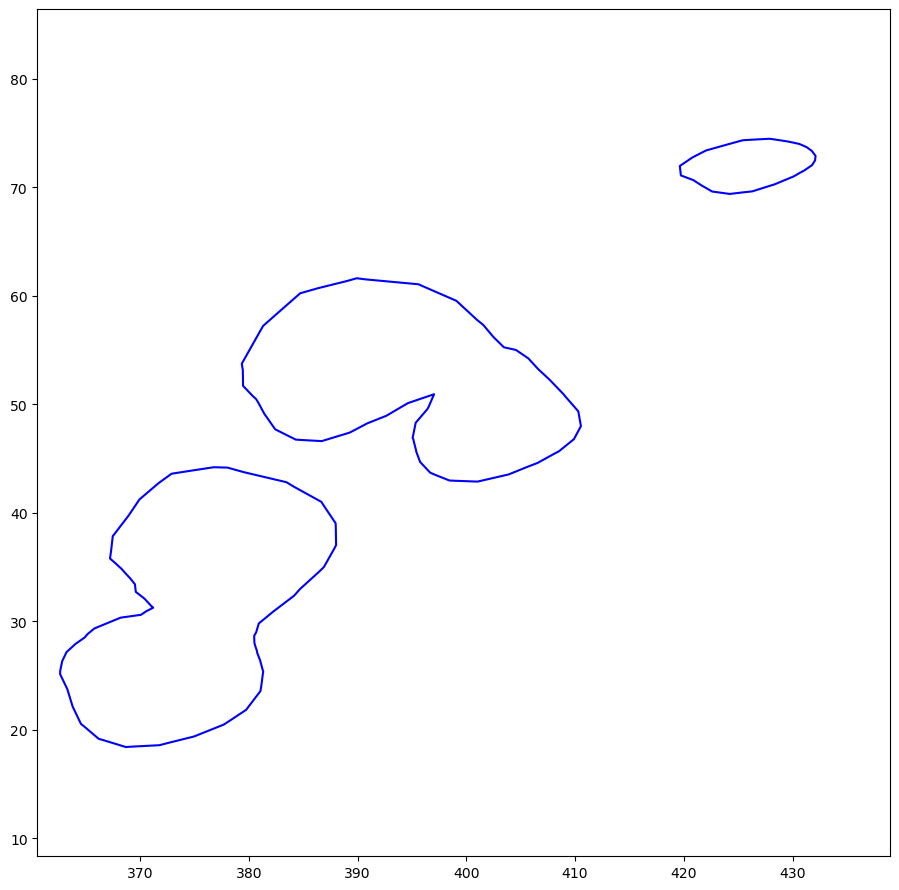

In [90]:
%matplotlib inline
from matplotlib.collections import LineCollection
from matplotlib import pyplot as plt
plt.figure(figsize=(11,11))

def CutbarZ(bar, Z):
    lam = (Z - bar.nodeback.p.z)/(bar.nodefore.p.z - bar.nodeback.p.z)    
    return Along(lam, bar.nodeback.p, bar.nodefore.p)

for barloop in barloops:
    poly = [ ]
    for bar in barloop:
        lam = (Z - bar.nodeback.p.z)/(bar.nodefore.p.z - bar.nodeback.p.z)    
        p = Along(lam, bar.nodeback.p, bar.nodefore.p)
        poly.append((p[0], p[1]))
    poly.append(poly[0])
    lc = LineCollection([poly], color="blue")
    plt.gca().add_collection(lc)
rex2 = 2
plt.xlim(tbm.xlo-rex2, tbm.xhi+rex2)
plt.ylim(tbm.ylo-rex2, tbm.yhi+rex2)
plt.show()

In [81]:
barloops[-2]